## Srujana Nevoji

## MSCS 634: Advanced Big Data and Data Mining

## Lab 1: Data Visualization, Preprocessing, and Statistical Analysis using Python in Jupyter Notebook


In [12]:
import pandas as pd

df = pd.read_csv("Sales_Data.csv")

df.head()

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Ship_Date,Units_Sold,Unit_SellingPrice,Unit_MakingCost
0,Central America and the Caribbean,Antigua and Barbuda,Baby Food,Online,M,12/20/2013,957081544.0,01-11-2014,552,255.28,159.42
1,Central America and the Caribbean,Panama,Snacks,Offline,C,07-05-2010,301644504.0,7/26/2010,2167,152.58,97.44
2,Europe,Czech Republic,Beverages,Offline,C,09-12-2011,478051030.0,9/29/2011,4778,47.45,31.79
3,Asia,North Korea,Cereal,Offline,L,5/13/2010,892599952.0,6/15/2010,9016,205.70,117.11
4,Asia,Sri Lanka,Snacks,Offline,C,7/20/2015,571902596.0,7/27/2015,7542,152.58,97.44


## 2. Data Visualization

### Histogram of Units Sold

This histogram shows the distribution of units sold across all sales records. It helps identify common sales volumes and the overall shape of the distribution.

Matplotlib is building the font cache; this may take a moment.


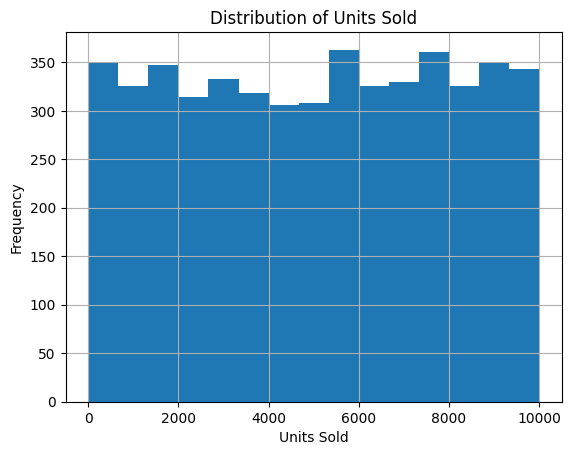

In [16]:
import matplotlib.pyplot as plt

df['Units_Sold'].hist(bins=15)

plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')

plt.show()

### Sales Channel Analysis

This bar chart compares the number of orders across different sales channels.

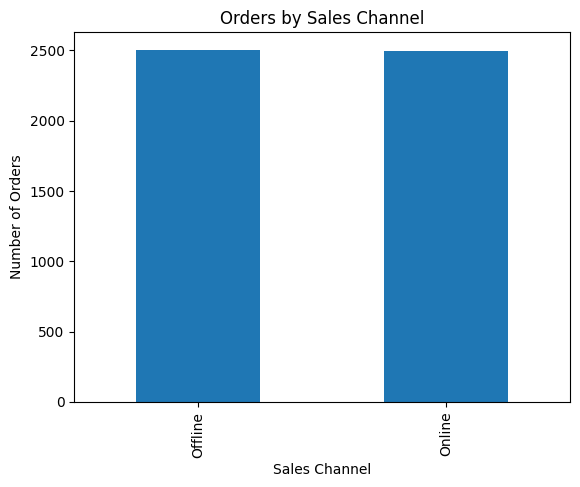

In [17]:
df['Sales_Channel'].value_counts().plot(kind='bar')

plt.title('Orders by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Number of Orders')

plt.show()

### Box Plots

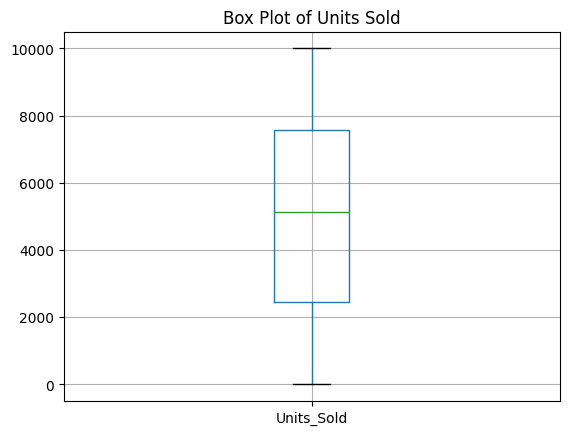

In [18]:
df.boxplot(column='Units_Sold')

plt.title('Box Plot of Units Sold')

plt.show()

## 3.Data Preprocessing

### Handling missing Values

In [19]:
df.isnull().sum()

Region                0
Country               0
Item_Type            11
Sales_Channel         0
Order_Priority        0
Order_Date            0
Order_ID              3
Ship_Date             0
Units_Sold            0
Unit_SellingPrice     0
Unit_MakingCost       0
dtype: int64

In [20]:
df.fillna(df.select_dtypes(include='number').mean(),
          inplace=True)

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Ship_Date,Units_Sold,Unit_SellingPrice,Unit_MakingCost
0,Central America and the Caribbean,Antigua and Barbuda,Baby Food,Online,M,12/20/2013,9.570815e+08,01-11-2014,552,255.28,159.42
1,Central America and the Caribbean,Panama,Snacks,Offline,C,07-05-2010,3.016445e+08,7/26/2010,2167,152.58,97.44
2,Europe,Czech Republic,Beverages,Offline,C,09-12-2011,4.780510e+08,9/29/2011,4778,47.45,31.79
3,Asia,North Korea,Cereal,Offline,L,5/13/2010,8.926000e+08,6/15/2010,9016,205.70,117.11
4,Asia,Sri Lanka,Snacks,Offline,C,7/20/2015,5.719026e+08,7/27/2015,7542,152.58,97.44
...,...,...,...,...,...,...,...,...,...,...,...
4995,Australia and Oceania,New Zealand,Household,Offline,C,04-03-2015,2.179845e+08,4/20/2015,5305,668.27,502.54
4996,Middle East and North Africa,Azerbaijan,Clothes,Offline,L,8/17/2014,1.697481e+08,10-02-2014,1077,109.28,35.84
4997,Asia,Myanmar,Baby Food,Offline,H,11/23/2016,5.485477e+08,12-10-2016,5204,255.28,159.42
4998,Europe,Finland,Clothes,Online,L,4/22/2014,5.485477e+08,05-11-2014,9410,109.28,35.84


In [21]:
df.isnull().sum()

Region                0
Country               0
Item_Type            11
Sales_Channel         0
Order_Priority        0
Order_Date            0
Order_ID              0
Ship_Date             0
Units_Sold            0
Unit_SellingPrice     0
Unit_MakingCost       0
dtype: int64

### Outlier Detection and Removel

In [22]:
Q1 = df['Units_Sold'].quantile(0.25)

Q3 = df['Units_Sold'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 2453.0
Q3 = 7576.25
IQR = 5123.25


In [23]:
lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[(df['Units_Sold'] < lower) |
              (df['Units_Sold'] > upper)]

outliers

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Ship_Date,Units_Sold,Unit_SellingPrice,Unit_MakingCost


In [24]:
df_clean = df[(df['Units_Sold'] >= lower) &
              (df['Units_Sold'] <= upper)]

df_clean.shape

(5000, 11)

### Data Reduction

In [25]:
df.shape

(5000, 11)

In [26]:
sample_df = df.sample(frac=0.5,
                      random_state=42)

sample_df.shape

(2500, 11)

In [27]:
reduced_df = sample_df.drop(
    columns=['Order_ID']
)

reduced_df.head()

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Ship_Date,Units_Sold,Unit_SellingPrice,Unit_MakingCost
1501,Sub-Saharan Africa,Seychelles,Vegetables,Offline,C,4/18/2013,5/27/2013,1613,154.06,90.93
2586,Europe,Vatican City,Fruits,Offline,H,1/24/2015,03-02-2015,6813,9.33,6.92
2653,Europe,Ukraine,Meat,Offline,M,6/18/2014,07-02-2014,9377,421.89,364.69
1055,Asia,India,Personal Care,Offline,C,6/23/2012,7/19/2012,3320,81.73,56.67
705,Sub-Saharan Africa,Chad,Snacks,Offline,C,8/25/2016,9/15/2016,7324,152.58,97.44


### Data Scaling and Discretization

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

reduced_df['Units_Sold_Scaled'] = scaler.fit_transform(
    reduced_df[['Units_Sold']]
)

reduced_df[['Units_Sold',
            'Units_Sold_Scaled']].head()

,Units_Sold,Units_Sold_Scaled
1501,1613,0.161504
2586,6813,0.682807
2653,9377,0.939850
1055,3320,0.332632
705,7324,0.734035


In [29]:
reduced_df['Sales_Category'] = pd.cut(
    reduced_df['Units_Sold'],
    bins=3,
    labels=['Low','Medium','High']
)

reduced_df[['Units_Sold',
            'Sales_Category']].head()

,Units_Sold,Sales_Category
1501,1613,Low
2586,6813,High
2653,9377,High
1055,3320,Low
705,7324,High


## 4.Statistical Analysis

### General Overview of Data

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Region             5000 non-null   str    
 1   Country            5000 non-null   str    
 2   Item_Type          4989 non-null   str    
 3   Sales_Channel      5000 non-null   str    
 4   Order_Priority     5000 non-null   str    
 5   Order_Date         5000 non-null   str    
 6   Order_ID           5000 non-null   float64
 7   Ship_Date          5000 non-null   str    
 8   Units_Sold         5000 non-null   int64  
 9   Unit_SellingPrice  5000 non-null   float64
 10  Unit_MakingCost    5000 non-null   float64
dtypes: float64(3), int64(1), str(7)
memory usage: 429.8 KB


In [31]:
df.describe()

,Order_ID,Units_Sold,Unit_SellingPrice,Unit_MakingCost
count,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,5.485477e+08,5030.698200,265.745564,187.494144
std,2.593003e+08,2914.515427,218.716695,176.416280
min,1.000909e+08,2.000000,9.330000,6.920000
25%,3.203498e+08,2453.000000,81.730000,35.840000
50%,5.521214e+08,5123.000000,154.060000,97.440000
75%,7.685650e+08,7576.250000,437.200000,263.330000
max,9.998797e+08,9999.000000,668.270000,524.960000


### Central Tendency Measures

In [32]:
print("Minimum:",
      df['Units_Sold'].min())

print("Maximum:",
      df['Units_Sold'].max())

print("Mean:",
      df['Units_Sold'].mean())

print("Median:",
      df['Units_Sold'].median())

print("Mode:",
      df['Units_Sold'].mode()[0])

Minimum: 2
Maximum: 9999
Mean: 5030.6982
Median: 5123.0
Mode: 2


### Dispersion Measures

In [33]:
Range = df['Units_Sold'].max() - \
        df['Units_Sold'].min()

Q1 = df['Units_Sold'].quantile(.25)

Q3 = df['Units_Sold'].quantile(.75)

IQR = Q3 - Q1

Variance = df['Units_Sold'].var()

StdDev = df['Units_Sold'].std()

print("Range =", Range)
print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Variance =", Variance)
print("Standard Deviation =", StdDev)

Range = 9997
Q1 = 2453.0
Q3 = 7576.25
IQR = 5123.25
Variance = 8494400.172751311
Standard Deviation = 2914.515426747869


### Correlation Analysis

The correlation matrix helps identify relationships between numerical variables in the dataset.

In [34]:
corr = df[['Units_Sold',
           'Unit_SellingPrice',
           'Unit_MakingCost']].corr()

corr

,Units_Sold,Unit_SellingPrice,Unit_MakingCost
Units_Sold,1.000000,-0.017492,-0.019712
Unit_SellingPrice,-0.017492,1.000000,0.986231
Unit_MakingCost,-0.019712,0.986231,1.000000


In [1]:
import os
print(os.getcwd())

/Users/sandeepnemli
